# 🎬 프로젝트 : 네이버 영화리뷰 감성분석 도전하기

본 프로젝트에서는 영어 리뷰가 아닌, 15만 건의 **Naver Sentiment Movie Corpus(nsmc)** 한국어 텍스트 데이터를 활용해 긍정/부정을 분류하는 딥러닝 감성 분석 모델을 구축합니다. 나아가 방대한 코퍼스로 사전 훈련된 **한국어 Word2Vec 모델**을 전이 학습(Transfer Learning)을 통해 결합하여 획기적인 모델 성능 향상을 도모하는 것을 목표로 합니다.


## Step 0. 데이터 및 모델링에 필요한 필수 라이브러리 일괄 로드
향후 진행될 데이터의 전처리, 텐서 변환, PyTorch 딥러닝 기반 모델링, 그래프 시각화 그리고 Gensim 임베딩 처리 과정에서 사용될 파이썬 핵심 라이브러리들을 미리 호출합니다.


In [5]:
# 파일 입출력 및 데이터/배열 핸들링
import os
import pandas as pd
import numpy as np
import urllib.request
from collections import Counter

# 데이터 스플릿 및 시각화 도구
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# NLP 텍스트 토큰화 처리를 위한 형태소 분석기 (윈도우 최적화 Okt)
from konlpy.tag import Okt

# 딥러닝 프레임워크 (PyTorch 환경)
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 워드 임베딩 분석 및 로드
import gensim
from gensim.models import Word2Vec
from gensim.models.keyedvectors import Word2VecKeyedVectors

# 노트북에서 그래프가 바로 보이도록 설정
%matplotlib inline

print("모든 라이브러리 로딩 및 파이토치 버전 확인 완료!")
print(f"PyTorch Version: {torch.__version__}")


모든 라이브러리 로딩 및 파이토치 버전 확인 완료!
PyTorch Version: 2.7.1+cu118


In [1]:
import pandas
import konlpy
import gensim

print(pandas.__version__)
print(konlpy.__version__)
print(gensim.__version__)

2.3.3
0.6.0
4.4.0


## Step 1. 데이터 준비 및 데이터로더 구성

본 단계에서는 네이버 영화 리뷰 말뭉치(NSMC) 데이터를 파이썬 환경으로 로드하고, 딥러닝 모델이 학습할 수 있는 숫자 형태(Index)로 전처리하는 전 과정을 수행합니다. 

데이터 파이프라인 구축을 위해 다음의 세부 절차로 `load_data()` 함수를 설계 및 실행하였습니다.
1. **데이터 정제(Cleaning)**: 판다스(Pandas)를 이용하여 원본 `.txt` 파일 로드 후, 문서의 중복값 및 결측치(`NaN`) 행을 완전히 제거.
2. **형태소 분석(Tokenization)**: 윈도우 환경 최적화를 고려하여 `Okt` 형태소 분석기를 적용, 한국어 텍스트 문장을 최소 의미 단위(형태소)로 토큰화.
3. **불용어 제거(Stopword Removal)**: '의', '가', '이', '은' 등 모델 학습에 기여도가 0에 수렴하는 불필요한 한국어 조사와 어미를 사전 정의하여 리스트에서 제외.
4. **어휘 사전 구축(Vocab Building)**: 토큰화된 단어들의 출현 빈도(`Counter`)를 계산하고, 빈도수가 높은 상위 10,000개 단어만 추출해 `word_to_index` 형태의 사전을 정립. `<PAD>`, `<BOS>`, `<UNK>`, `<UNUSED>` 등 4개의 필수 특수 토큰을 0~3번 인덱스로 할당.
5. **텍스트 데이터 정수 인코딩(Encoding)**: 완성된 딕셔너리를 바탕으로 원래 텍스트 문장을 숫자 시퀀스 리스트로 매핑하여 `X_train`, `X_test` 등으로 반환. 
6. **디코딩(Decoding) 검증**: 구축된 시퀀스를 사람이 읽을 수 있는 텍스트로 되돌리는 함수를 정의하여 인코딩-디코딩 알고리즘의 정상 동작을 교차 검증.



In [2]:
import pandas as pd
import os

# 현재 폴더 안의 'data' 폴더에 있는 파일을 읽어옵니다.
data_dir = './data/'
train_data = pd.read_table(os.path.join(data_dir, 'ratings_train.txt'))
test_data = pd.read_table(os.path.join(data_dir, 'ratings_test.txt'))

train_data.head()


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [4]:
# Mecab 대신 Okt를 불러옵니다.
from konlpy.tag import Okt
import numpy as np
from collections import Counter

# tokenizer를 Okt()로 변경해줍니다.
tokenizer = Okt()
stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

def load_data(train_data, test_data, num_words=10000):
    train_data.drop_duplicates(subset=['document'], inplace=True)
    train_data = train_data.dropna(how = 'any')
    test_data.drop_duplicates(subset=['document'], inplace=True)
    test_data = test_data.dropna(how = 'any')

    X_train = []
    for sentence in train_data['document']:
        temp_X = tokenizer.morphs(sentence) # 토큰화
        temp_X = [word for word in temp_X if not word in stopwords] # 불용어 제거
        X_train.append(temp_X)

    X_test = []
    for sentence in test_data['document']:
        temp_X = tokenizer.morphs(sentence) # 토큰화
        temp_X = [word for word in temp_X if not word in stopwords] # 불용어 제거
        X_test.append(temp_X)

    words = np.concatenate(X_train).tolist()
    counter = Counter(words)
    counter = counter.most_common(10000-4)
    vocab = ['<PAD>', '<BOS>', '<UNK>', '<UNUSED>'] + [key for key, _ in counter]
    word_to_index = {word:index for index, word in enumerate(vocab)}

    def wordlist_to_indexlist(wordlist):
        return [word_to_index[word] if word in word_to_index else word_to_index['<UNK>'] for word in wordlist]

    X_train = list(map(wordlist_to_indexlist, X_train))
    X_test = list(map(wordlist_to_indexlist, X_test))

    return X_train, np.array(list(train_data['label'])), X_test, np.array(list(test_data['label'])), word_to_index

# ⚠️ Okt는 한글 전처리 품질이 좋지만, 데이터량이 많으면 Mecab보다 속도가 다소 느립니다. 
# 이 셀을 실행하고 완료될 때까지 시간이 조금 걸릴 수 있으니 (약 3~5분 내외) 차분히 기다려주세요!
X_train, y_train, X_test, y_test, word_to_index = load_data(train_data, test_data)
print("✅ 데이터 전처리가 성공적으로 완료되었습니다!")


✅ 데이터 전처리가 성공적으로 완료되었습니다!


In [6]:
# 1. 인덱스 포지션을 키(key)로, 단어를 값(value)으로 가지는 역방향 딕셔너리 생성
index_to_word = {index: word for word, index in word_to_index.items()}

# 2. 숫자 벡터로 인코딩된 문장을 원래의 텍스트 스트링으로 복원하는 함수 정의
def get_decoded_sentence(encoded_sentence, index_to_word):
    # 인코딩 시 추가된 <BOS> 등의 특수 토큰 처리에 따라 디코딩 시작점을 지정할 수 있음. 
    # 현재 load_data 구조상 <BOS>가 문장 맨 앞에 강제 추가되지 않았으므로 전체 인덱스를 디코딩함.
    # 만약 사전에 없는 단어 인덱스일 경우 '<UNK>' 토큰으로 대체하여 반환 처리.
    return ' '.join(index_to_word[index] if index in index_to_word else '<UNK>' for index in encoded_sentence)

# 3. 모델에 입력될 훈련 데이터의 첫 번째 샘플 디코딩 검증 출력
print(f"인코딩된 첫 번째 훈련 데이터 샘플 (정수 시퀀스):")
print(X_train[0]) 

print(f"\n디코딩된 첫 번째 훈련 데이터 샘플 (텍스트 시퀀스):")
print(get_decoded_sentence(X_train[0], index_to_word))

# 4. 해당 샘플의 원래 라벨 확인 (0: 부정, 1: 긍정)
print(f"\n해당 데이터 라벨: {y_train[0]}")


인코딩된 첫 번째 훈련 데이터 샘플 (정수 시퀀스):
[49, 451, 6, 16, 7140, 670]

디코딩된 첫 번째 훈련 데이터 샘플 (텍스트 시퀀스):
아 더빙 .. 진짜 짜증나네요 목소리

해당 데이터 라벨: 0


## Step 2. 모델 구성을 위한 데이터 분석 및 가공 (Padding)
딥러닝 모델의 임베딩 레이어 및 입력층은 고정된 길이의 텐서(Tensor)를 요구하나, 텍스트 데이터의 문장 길이는 모두 상이함. 
따라서 전체 훈련/테스트 데이터셋을 병합하여 문장 길이에 대한 통계적 분포(평균, 최대값, 표준편차)를 산출하고, 대다수의 데이터를 보존할 수 있는 최적의 최대 문장 길이(`maxlen`)를 도출함. 이후 해당 길이를 초과하는 데이터는 절삭하고, 부족한 데이터는 0(`<PAD>`)값으로 패딩(Padding)하여 최종 입력 텐서의 규격을 단일화함.


In [7]:
# 1. 훈련 데이터쌍과 테스트 데이터쌍을 하나의 리스트로 결합하여 전체 시퀀스 길이 통계를 분석
total_data_text = list(X_train) + list(X_test)

# 2. 각 샘플(문장)별 토큰(단어) 개수를 산출하여 numpy 배열로 변환
num_tokens = np.array([len(tokens) for tokens in total_data_text])

# 3. 전체 데이터셋의 문장 길이 분포(평균, 최대, 표준편차) 확인
print(f"문장 길이 평균: {np.mean(num_tokens):.2f}")
print(f"문장 길이 최대: {np.max(num_tokens)}")
print(f"문장 길이 표준편차: {np.std(num_tokens):.2f}")

# 4. 적정 최대 문장 길이(maxlen)를 객관적 수식(평균 + 2 * 표준편차)을 통해 지정
# 이는 통계적으로 전체 데이터의 특성을 최대한 보존하면서 학습 리소스를 불필요하게 낭비하지 않는 적정 설계치임.
max_tokens = np.mean(num_tokens) + 2 * np.std(num_tokens)
maxlen = int(max_tokens)
print(f"\n최종 산출된 패딩 컷오프(maxlen): {maxlen}")

# 5. 설정한 maxlen 값 이내에 전체 문장의 몇 %가 온전히 포함되는지 보존율 계산
retention_rate = np.sum(num_tokens < max_tokens) / len(num_tokens)
print(f"전체 문장의 약 {retention_rate * 100:.2f}%가 설정된 maxlen 통제 범위 내에 온전하게 포함됨.")

# 6. 문장의 길이가 maxlen을 초과하지 않고 모자란 경우를 대비한 패딩 함수 구현
# PyTorch의 pad_sequence를 사용해도 되지만, 가장 직관적이고 커스텀이 쉬운 넘파이 방식 함수를 정의 
def pad_sequences(data, maxlen, padding_value=0):
    padded_data = []
    for sentence in data:
        if len(sentence) < maxlen:
            # 설정 길이보다 짧은 경우 부족한 만큼 우측 끝에 <PAD>(0)를 채워 넣음
            sentence = sentence + [padding_value] * (maxlen - len(sentence))
        else:
            # 설정 길이보다 긴 문장의 경우 maxlen 길이만큼 자름(Sliding)
            sentence = sentence[:maxlen]
        padded_data.append(sentence)
    return np.array(padded_data)

# 7. 패딩 기능을 호출하여 훈련셋과 테스트셋에 동일하게 덮어 적용
x_train_padded = pad_sequences(X_train, maxlen, padding_value=word_to_index['<PAD>'])
x_test_padded = pad_sequences(X_test, maxlen, padding_value=word_to_index['<PAD>'])

# 8. 최종적으로 딥러닝 연산 환경에 맞춰 넘파이 배열 포맷을 PyTorch Tensor(Long 형)로 캐스팅
X_train_tensor = torch.tensor(x_train_padded, dtype=torch.long)
X_test_tensor = torch.tensor(x_test_padded, dtype=torch.long)

# 9. 결과 데이터 형태(Shape) 매칭 검증
print(f"\n최종 변환 완료 훈련 데이터 Shape: {X_train_tensor.shape}")
print(f"최종 변환 완료 테스트 데이터 Shape: {X_test_tensor.shape}")


문장 길이 평균: 12.81
문장 길이 최대: 95
문장 길이 표준편차: 10.40

최종 산출된 패딩 컷오프(maxlen): 33
전체 문장의 약 93.47%가 설정된 maxlen 통제 범위 내에 온전하게 포함됨.

최종 변환 완료 훈련 데이터 Shape: torch.Size([146182, 33])
최종 변환 완료 테스트 데이터 Shape: torch.Size([49157, 33])


## Step 3. 모델 구성 및 Validation 데이터 스플릿
실제 모델 훈련 루프에 진입하기 앞서, 보유한 학습 데이터(`X_train`) 전부를 훈련에만 소진하지 않도록 `scikit-learn`을 활용해 전체의 20%를 검증용 데이터(Validation Set)로 분리한다. 이는 훈련 중 발생하는 과적합(Overfitting) 현상을 모니터링하기 위한 필수 장치이다. 

이후 PyTorch의 `nn.Module`을 상속받아 자연어 처리에 쓰이는 대표적인 딥러닝 아키텍처 3종을 각각 정의한다. 구조는 모두 동일하게 입력층 직후 학습용 임베딩 층(`nn.Embedding`)을 통과시키며, 이를 기초로 긍정(1)/부정(0) 확률을 뱉는 `Sigmoid` 통과 1차원 선형 층으로 마무리된다.


In [9]:
# 1. 사이킷런의 train_test_split을 사용하여 빠르고 균일하게 8:2 비율로 데이터 스플릿
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_tensor, y_train_tensor, test_size=0.2, random_state=42
)

print(f"훈련용 데이터셋 Shape: {X_train_split.shape}")
print(f"검증용 데이터셋 Shape: {X_val_split.shape}")

# 2. 임베딩 및 모델 구현에 사용될 하이퍼파라미터 공통 정의
vocab_size = 10000   # 구축한 어휘 사전의 크기
word_vector_dim = 16 # 초기 학습에서 부여할 깡통 워드 벡터의 차원 수 (추후 사전학습 모델 300으로 변경 대상)


훈련용 데이터셋 Shape: torch.Size([116945, 33])
검증용 데이터셋 Shape: torch.Size([29237, 33])


## Step 3-1. 모델 구성 1: RNN(LSTM) 기반 아키텍처 설계
자연어 문장의 순차적(Sequential) 특성을 처리하기 위해 순환신경망 알고리즘인 장단기메모리(LSTM, Long Short-Term Memory) 구조를 채택한다. 

네이버 영화 리뷰 문맥의 장기 의존성(Long-term dependencies) 패턴을 선행적으로 기억(Memory)한 상태에서 긍정과 부정의 이진(Binary) 분류 값을 도출하기 위한 심층 신경망(Deep Neural Network)을 PyTorch의 `nn.Module` 기반 클래스로 구축한다. 


In [10]:
# LSTM 병렬 구조를 포함한 감성 분석 모델 클래스 정의
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        # 상위 모듈인 nn.Module 클래스의 생성자 계승 및 초기화
        super(LSTMModel, self).__init__()
        
        # 입력된 단어 인덱스 번호를 (vocab_size, word_vector_dim) 형태의 고밀도 벡터로 매핑하는 임베딩 층 정의
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        
        # 시계열 연산을 위한 LSTM 층 설계
        # 배치(Batch) 차원을 데이터 구조가 허용하는 가장 큰 선두 축(1차원)에 강제 할당하기 위한 batch_first 활성화
        self.lstm = nn.LSTM(input_size=word_vector_dim, hidden_size=8, batch_first=True)
        
        # 모델의 최종 논리적 요약을 위한 완전 연결층(Fully Connected Layer) 1 정의 (은닉층 차원: 8 -> 8)
        self.fc1 = nn.Linear(8, 8)
        # 이진 감성 분류 예측 값을 출력하기 위한 완전 연결층 2 정의 (출력 노드: 1)
        self.fc2 = nn.Linear(8, 1)

    def forward(self, x):
        # 1. 자연어 시퀀스 x를 밀집 벡터로 변환하는 임베딩 층 투과 연산 수행
        x = self.embedding(x)
        
        # 2. LSTM 엔진 통과 및 출력값 x, 은닉상태(h_n, c_n) 도출
        x, (hn, cn) = self.lstm(x)
        
        # 3. 마지막 타임스텝의 LSTM 출력 벡터만 최종 문맥으로 압축하여 사용 
        x = x[:, -1, :]
        
        # 4. 차원 변환 보존을 위해 활성 함수 ReLU를 투과시키어 완전 연결층 1에서 비선형성 보강
        x = F.relu(self.fc1(x))
        
        # 5. 최종 시그모이드(Sigmoid) 함수를 통해 (0~1) 범위의 모델 확률로 이진 논리값 산출 
        x = torch.sigmoid(self.fc2(x))
        
        return x

# 정의된 초기 하이퍼파라미터(10000 x 16) 스펙을 가지고 모델 인스턴스 초기화 
model_1 = LSTMModel(vocab_size, word_vector_dim)

# 구축된 신경망(Model_1) 계층의 각 논리 구조 및 파라미터 맵 개요를 화면에 출력
print(model_1)


LSTMModel(
  (embedding): Embedding(10000, 16)
  (lstm): LSTM(16, 8, batch_first=True)
  (fc1): Linear(in_features=8, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)


## Step 3-2. 모델 구성 2: CNN(1D Convolution) 기반 아키텍처 설계
시계열 연산에 국한된 RNN의 한계를 보완하기 위해 이미지 처리에 널리 쓰이는 합성곱 신경망(Convolutional Neural Network) 로직을 자연어 토큰에 맞춘 1차원(1D)으로 변형하여 적용한다. 

지정된 윈도우(커널) 사이즈만큼 문서를 병렬 스캐닝하며 단어의 로컬 문맥 피처(Feature)를 빠르게 뽑아내기 위해 `nn.Conv1d` 필터와 `nn.MaxPool1d` 층들을 교차 적용한 후, 이진(Binary) 분류 값을 도출하는 심층 신경망을 PyTorch의 `nn.Module` 기반 클래스로 구축한다. 


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 앞서 정의된 메모리의 글로벌 하이퍼파라미터(vocab_size=10000, word_vector_dim=16)를 그대로 사용 
# CNN 기반 감성 분석 모델 클래스 정의
class CNNModel(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        # 상위 모듈인 nn.Module 클래스의 생성자 계승 및 초기화
        super(CNNModel, self).__init__()
        
        # 입력된 단어 인덱스를 해당 차원의 고밀도 벡터 연속으로 매핑하는 임베딩 층 정의
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        
        # 1차원 특징 추출용 합성곱 1계층 정의 
        # (입력 채널: 16차원 벡터, 출력 피처맵: 16채널, 한번에 판독할 단어 커널 크기: 3)
        self.conv1 = nn.Conv1d(word_vector_dim, 16, kernel_size=3)
        
        # 두 번째 특징 추출용 합성곱 2계층 정의 (입/출력 채널: 16, 커널 크기: 3)
        self.conv2 = nn.Conv1d(16, 16, kernel_size=3)
        
        # 주요 합성곱 연산 사이에서 로컬 문맥 중 가장 강력한 특징을 추상화하는 풀링 층 정의 (단위: 2)
        self.pool = nn.MaxPool1d(kernel_size=2)
        
        # 전체 시퀀스에 걸쳐 출력 긍/부정 결정에 가장 유효한 전역 치수를 하나로 압축하는 층 
        self.global_max_pooling = nn.AdaptiveMaxPool1d(1)
        
        # 논리 연산의 비선형성을 강화할 완전 연결층 1구간 정의 (입력: 16, 출력: 8)
        self.fc1 = nn.Linear(16, 8)
        # 활성 함수 객체 지정
        self.relu = nn.ReLU()
        # 최종 모델 확률 도달용 완전 연결층 2구간 정의 (입력: 8, 출력 노드: 1)
        self.fc2 = nn.Linear(8, 1)    
        # 이진 감성 분류 예측 값을 퍼센트 치환용 함수 객체 지정
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # 1. 자연어 시퀀스를 밀집 벡터로 변환하는 임베딩 연산 
        x = self.embedding(x)
        
        # 2. PyTorch의 Conv1d 엔진의 호환 구조인 (Batch, Channel, Length)에 맞게 축(Axis) 전치 교환
        x = x.permute(0, 2, 1)
        
        # 3. 합성곱 1계층 투과 후 ReLU를 통한 비선형화 제어
        x = self.conv1(x)
        x = self.relu(x)
        
        # 4. 풀링 레이어로 피처맵의 정보 크기를 압축 
        x = self.pool(x)
        
        # 5. 합성곱 2계층 투과 후 다시 ReLU 비선형화 제어 (고급 패턴 추출)
        x = self.conv2(x)
        x = self.relu(x)
        
        # 6. GlobalMaxPool 층으로 시퀀스 전체 채널 중 단일 최대 치수 채집
        x = self.global_max_pooling(x)
        
        # 7. 완전 연결 층 통과를 위한 텐서의 축소 및 평탄화(Flatten) 시도
        x = x.view(x.size(0), -1)
        
        # 8. FC 완전 연결층 1구간 및 활성화 투과
        x = self.fc1(x)
        x = self.relu(x)
        
        # 9. 최종 출력 1 노드 FC 계층과 시그모이드를 투과하여 타겟이 긍정(1)인지 평가 확률 발현
        x = self.fc2(x)
        x = self.sigmoid(x)
        
        return x

# 정의된 초기 하이퍼파라미터 스펙을 가지고 모델 인스턴스 2 초기화 
model_2 = CNNModel(vocab_size, word_vector_dim)

# 구축된 1D CNN 신경망 계층의 각 논리 구조 파라미터를 화면 출력
print(model_2)


CNNModel(
  (embedding): Embedding(10000, 16)
  (conv1): Conv1d(16, 16, kernel_size=(3,), stride=(1,))
  (conv2): Conv1d(16, 16, kernel_size=(3,), stride=(1,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_max_pooling): AdaptiveMaxPool1d(output_size=1)
  (fc1): Linear(in_features=16, out_features=8, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


## Step 3-3. 모델 구성 3: Global MaxPooling 1D 기반 아키텍처 설계
복잡한 시계열이나 필터 스캐닝 연산을 배제하고, 문장의 모든 단어 벡터 중 가장 핵심적인(수치적으로 강력한) 차원(Feature) 데이터만을 직접적으로 차출하는 풀링 전용 네트워크를 설계한다. 

자연어 문맥 파악의 정교함은 다소 떨어질 수 있으나, 매우 빠른 연산 속도와 과적합 방지 효과를 지니고 있어 벤치마크 혹은 단순 이진 분류 태스크에서 높은 효율성을 보인다.


In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 앞서 정의된 메모리의 글로벌 하이퍼파라미터(vocab_size=10000, word_vector_dim=16)를 동일 적용
# GlobalMaxPool 기반 감성 분석 모델 클래스 정의
class GlobalMaxPoolModel(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        # 상위 모듈인 nn.Module 클래스의 생성자 계승 및 초기화
        super(GlobalMaxPoolModel, self).__init__()
        
        # 10000개 어휘 사전 인덱스를 16차원의 고밀도 벡터 연속으로 매핑하는 임베딩 층 정의
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        
        # 문장 전체 영역을 하나로 압축하여 단일 최댓값을 반환하는 Adaptive 전역 풀링 층 정의
        self.global_max_pooling = nn.AdaptiveMaxPool1d(1)
        
        # 압축된 16차원의 벡터를 8 논리 노드로 줄이는 완전 연결층 1 정의
        self.fc1 = nn.Linear(word_vector_dim, 8)
        # 텐서 비선형성 보강용 함수 객체 지정
        self.relu = nn.ReLU()
        # 최종 모델 확률 도달용 완전 연결층 2구간 정의 (출력 노드: 1)
        self.fc2 = nn.Linear(8, 1)    
        # 이진 긍/부정 식별 퍼센트 치환용 함수 객체 지정
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # 1. 자연어 시퀀스를 밀집 벡터 행렬로 1차적 변환
        x = self.embedding(x)
        
        # 2. PyTorch 1D 풀링 엔진 호환을 위한 축(Axis) 전치 (Batch, Channel, Length)
        x = x.permute(0, 2, 1)
        
        # 3. 추가 컨볼루션 연산 없이 곧바로 전 채널 집계 최댓값 추출 수행
        x = self.global_max_pooling(x)
        
        # 4. 완전 연결 층 진입 구조 확보를 위한 텐서 평탄화(Flatten) 수행
        x = x.view(x.size(0), -1)
        
        # 5. FC 완전 연결층 1구간 및 활성화 함수 통과
        x = self.fc1(x)
        x = self.relu(x)
        
        # 6. 최종 출력 1 노드 FC 계층과 시그모이드를 투과하여 0~1 사이의 긍/부정 스코어 발현
        x = self.fc2(x)
        x = self.sigmoid(x)
        
        return x

# 정의된 초기 하이퍼파라미터 스펙을 가지고 모델 인스턴스 3 초기화 
model_3 = GlobalMaxPoolModel(vocab_size, word_vector_dim)

# 구축된 Global MaxPool 신경망 계층 구조를 화면 출력
print(model_3)


GlobalMaxPoolModel(
  (embedding): Embedding(10000, 16)
  (global_max_pooling): AdaptiveMaxPool1d(output_size=1)
  (fc1): Linear(in_features=16, out_features=8, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


## Step 3-4. (심화) 모델 구성 4: CNN-BiLSTM 하이브리드 최적화 모델 설계
작성된 모델 1, 2, 3의 장점을 수용하고 한국어 구어체의 특성을 반영하기 위해 CNN과 양방향 LSTM을 결합한 하이브리드 구조를 정의한다. 

CNN 레이어는 문장 내 국소적인 키워드 패턴을 조기에 추출하여 데이터 밀도를 높이며, 양방향 LSTM은 이를 전달받아 문장 전체의 맥락과 한국어 특유의 서술어 기반 감성 반전 패턴을 양방향으로 추론한다. 마지막으로 최대 풀링과 평균 풀링을 결합(Fusion)하여 모델의 판단 근거를 다각화한다.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 하이퍼파라미터 정의 (어휘 사전 10,000개, 임베딩 차원 16)
vocab_size = 10000
word_vector_dim = 16

class OptimizedHybridModel(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        # 상위 클래스 생성자 호출을 통한 모듈 초기화
        super(OptimizedHybridModel, self).__init__()
        
        # 1. 자연어 인덱스를 고밀도 수치 벡터로 변환하는 임베딩 층
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        
        # 2. 로컬 특징 추출기: 커널 크기 3의 1D CNN 필터를 통해 핵심 구문 패턴을 32개 채널로 추출
        self.conv = nn.Conv1d(in_channels=word_vector_dim, out_channels=32, kernel_size=3)
        
        # 3. 맥락 분석기: 추출된 특징들 사이의 순차적 관계를 양방향(Bidirectional)으로 분석하는 LSTM
        # 은닉 상태(Hidden size)를 16으로 설정하여 연산 효율화 도모
        self.lstm = nn.LSTM(input_size=32, hidden_size=16, batch_first=True, bidirectional=True)
        
        # 4. 정보 집약기: 시퀀스 전체에서 가장 강한 신호(Max)와 전반적인 흐름(Avg) 정보를 병렬 추출
        self.global_max_pool = nn.AdaptiveMaxPool1d(1)
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        
        # 5. 분류기: 양방향 LSTM의 결과(16*2=32)와 풀링 채널(32*2=64)을 통합하여 최종 긍/부정 확률 계산
        self.fc = nn.Linear(64, 1)
        # 과적합 방지를 위한 드롭아웃 레이어 (30% 확률)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # [데이터 흐름 1] 입력을 밀집 텐서로 변환
        x = self.embedding(x) # Shape: (Batch, Length, Dim)
        
        # [데이터 흐름 2] CNN 연산을 위해 채널과 길이 축 전치 (Batch, Dim, Length)
        x = x.permute(0, 2, 1) 
        # 합성곱 필터를 통과시켜 지역적 문맥 피처 추출 후 비선형 활성화 적용
        x = F.relu(self.conv(x)) 
        
        # [데이터 흐름 3] LSTM 입력 요구 조건에 맞게 다시 축 전치 (Batch, Length, Channels)
        x = x.permute(0, 2, 1)
        
        # [데이터 흐름 4] 양방향 LSTM을 투과시켜 문장 전/후방의 인과관계 가중치 산출
        # 출력 x는 (Batch, Length, 32)의 크기를 가짐 (Hidden 16 * 2방향)
        x, (h_n, c_n) = self.lstm(x)
        
        # [데이터 흐름 5] 풀링 연산을 위해 다시 축 변환 (Batch, 32, Length)
        x = x.permute(0, 2, 1)
        
        # [데이터 흐름 6] 전역 최대 풀링과 평균 풀링을 병렬 수행 후 1차원 평탄화
        p1 = self.global_max_pool(x).squeeze(2)
        p2 = self.global_avg_pool(x).squeeze(2)
        
        # [데이터 흐름 7] 추출된 정보 요약본을 합산 혹은 선택하여 특징 결합
        # 본 설계에서는 최대 풀링 결과 p1을 주 특징으로 채택
        combined = torch.cat([p1, p2], dim=1) 
        
        # [데이터 흐름 8] 드롭아웃 적용 후 완전 연결층과 시그모이드를 거쳐 이진 확률값 도출
        x = self.dropout(combined)
        x = torch.sigmoid(self.fc(x))
        
        return x

# 최적화 하이브리드 모델 인스턴스 초기화 
model_4 = OptimizedHybridModel(vocab_size, word_vector_dim)

# 구축된 하이브리드 신경망 계층 구조 및 파라미터 구성 출력
print(model_4)


OptimizedHybridModel(
  (embedding): Embedding(10000, 16)
  (conv): Conv1d(16, 32, kernel_size=(3,), stride=(1,))
  (lstm): LSTM(32, 16, batch_first=True, bidirectional=True)
  (global_max_pool): AdaptiveMaxPool1d(output_size=1)
  (global_avg_pool): AdaptiveAvgPool1d(output_size=1)
  (fc): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


## Step 4-0. 학습용 데이터 분리 및 DataLoader 구축
모델 훈련에 앞서, 전체 훈련 텐서(`X_train_tensor`)를 실 학습용 데이터(80%)와 성능 검증용 데이터(20%)로 분리한다. 분리된 각 데이터는 PyTorch의 `DataLoader`를 거쳐 배치(Batch) 사이즈 512 단위로 모델에 주입될 수 있는 반복자(Iterator) 형태로 변환된다.


In [17]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

# 1. 전체 훈련용 텐서(14.6만 건)를 8:2 비율로 무작위 분리하여 훈련/검증셋 생성
# 전처리 단계에서 생성한 X_train_tensor와 y_train_tensor를 소스로 사용함
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_tensor, y_train_tensor, test_size=0.2, random_state=42
)

# 2. PyTorch 전용 데이터셋 객체인 TensorDataset으로 맵핑 수행
train_dataset = TensorDataset(X_train_split, y_train_split)
val_dataset = TensorDataset(X_val_split, y_val_split)

# 3. 모델이 효율적으로 미니 배치를 학습할 수 있도록 DataLoader 반복자 구축
# 훈련 로더(train_loader)는 에포크마다 데이터를 섞어(shuffle) 학습 편향을 최소화함
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
# 검증 로더(val_loader)는 성능 측정 목적이므로 섞지 않고 순차적으로 평가함
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)

# 4. 연산을 수행할 하드웨어 장치(GPU 가속 여부)를 최종 확인 및 장치 변수화
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"✅ 데이터 분리 완료 (Train: {len(X_train_split)}, Val: {len(X_val_split)})")
print(f"✅ DataLoader 구축 성공. 현재 연산 장치: {device}")


✅ 데이터 분리 완료 (Train: 116945, Val: 29237)
✅ DataLoader 구축 성공. 현재 연산 장치: cuda


## Step 4-1. 모델 통합 훈련 루프 정의 및 실행 환경 구축
구축된 4가지 모델(LSTM, CNN, MaxPool, Hybrid)에 대해 일관된 훈련 프로토콜을 적용하기 위해 통합 훈련 함수 `train_model()`을 정의한다. 

해당 함수는 에포크(Epoch)별 손실값(Loss)과 정확도(Accuracy)를 기록하고, 각 학습 단계에 소요된 소요 시간을 분(Minute) 단위로 정교하게 측정하여 모델별 연산 효율성을 평가할 수 있게 설계됨. 학습 데이터는 8:2 비율로 분리된 `train_loader`와 `val_loader`를 통해 미니 배치 형태로 모델에 주입됨.


In [18]:
import time # 각 에포크별 학습 시간을 측정하기 위한 모듈 로드
import torch.optim as optim

# 1. 모델 개체와 이름을 입력받아 훈련을 수행하고 기록(History)을 반환하는 통합 함수 정의
def train_model(model, model_name, train_loader, val_loader, epochs=10):
    # 모델을 현재 사용 가능한 장치(GPU/CPU) 메모리로 이동
    model.to(device)
    # 이진 분류를 위한 표준 손실함수(Binary Cross Entropy) 정의
    criterion = nn.BCELoss()
    # 파라미터 최적화를 위한 Adam 알고리즘 선언 (Learning Rate: 0.001)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # 손실 및 정확도 추이 기록을 위한 딕셔너리 구조화
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    print(f"🚀 [{model_name}] 모델 학습을 시작합니다. (Device: {device})")

    for epoch in range(epochs):
        start_time = time.time() # 에포크 시작 시간 기록
        
        # --- [Training Phase] ---
        model.train() # 모델을 훈련 모드로 전환 (Dropout, BatchNorm 활성화)
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device) # 데이터를 장치로 복사
            optimizer.zero_grad() # 이전 루프의 그래디언트 초기화
            
            outputs = model(inputs) # 순전파(Forward) 연산 수행
            loss = criterion(outputs.squeeze(), labels) # 손실값 산출 (차원 일치 수행)
            loss.backward() # 역전파(Backpropagation) 수행
            optimizer.step() # 가중치(Weight) 업데이트

            running_loss += loss.item() * inputs.size(0) # 배치별 손실 누적
            predicted = (outputs.squeeze() > 0.5).float() # 0.5 기준 이진 판정
            correct += (predicted == labels).sum().item() # 정답 수 합산
            total += labels.size(0) # 전체 데이터 수 합산

        # 에포크 단위 평균 손실 및 정확도 계산 후 리스트 추가
        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = correct / total
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)

        # --- [Validation Phase] ---
        model.eval() # 모델을 평가 모드로 전환 (그래디언트 연산 중단 대비)
        v_loss, v_correct, v_total = 0.0, 0, 0

        with torch.no_grad(): # 검증 데이터에 대해서는 그래디언트 계산을 생략하여 메모리 절약
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs.squeeze(), labels)

                v_loss += loss.item() * inputs.size(0)
                predicted = (outputs.squeeze() > 0.5).float()
                v_correct += (predicted == labels).sum().item()
                v_total += labels.size(0)

        # 검증 세트 평균 지표 산술 및 기록
        epoch_val_loss = v_loss / len(val_loader.dataset)
        epoch_val_acc = v_correct / v_total
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        # 소요 시간 연산 (초 -> 분 단위 변환)
        end_time = time.time()
        epoch_mins = (end_time - start_time) / 60

        # 에포크 최종 결과 리포트 출력
        print(f"Epoch {epoch+1:02d}/{epochs} - Time: {epoch_mins:.2f}m - "
              f"Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.4f} | "
              f"Val_Loss: {epoch_val_loss:.4f}, Val_Acc: {epoch_val_acc:.4f}")

    print(f"✅ [{model_name}] 학습 완료.\n")
    return history

# 2. 훈련 함수 실행 가이드 (예시: 하이브리드 모델 10 Epoch 학습)
# history_hybrid = train_model(model_4, "Optimized_Hybrid", train_loader, val_loader, epochs=10)


## Step 4-2. 전 모델 순차 학습 실시 및 결과 가공 저장
구현된 4종의 신경망 모델(`LSTM`, `CNN`, `GlobalMaxPool`, `Optimized_Hybrid`)을 순차적으로 호출하여 학습을 진행한다. 학습이 완료된 후에는 모델별 마지막 에포크의 훈련 및 검증 지표를 수집하여 데이터프레임 형식으로 변환하고, 이를 로컬 환경에 `model_training_results.csv` 파일로 저장하여 객관적인 지표 비교의 근거 자료로 활용한다.


In [23]:
# 모델 생성에 필요한 하이퍼파라미터 정의 (기 정립된 수치 준수)
vocab_size = 10000
word_vector_dim = 16

# 1. 모델 1: LSTM 아키텍처 초기화
model_1 = LSTMModel(vocab_size, word_vector_dim)

# 2. 모델 2: 1D CNN 아키텍처 초기화 (중첩 레이어 구조)
model_2 = CNNModel(vocab_size, word_vector_dim)

# 3. 모델 3: Global Max Pooling 아키텍처 초기화
model_3 = GlobalMaxPoolModel(vocab_size, word_vector_dim)

# 4. 모델 4: CNN-BiLSTM 하이브리드 최적화 아키텍처 초기화
model_4 = OptimizedHybridModel(vocab_size, word_vector_dim)

print("✅ 4종의 감성 분석 모델 객체(model_1 ~ model_4) 초기화 완료.")


✅ 4종의 감성 분석 모델 객체(model_1 ~ model_4) 초기화 완료.


In [24]:
import pandas as pd
import os

# 1. 모든 모델의 전체 history 객체를 개별적으로 담을 마스터 딕셔너리 생성
# 시각화 시 histories['LSTM'] 형식으로 즉시 접근 가능
histories = {}

# 2. CSV 파일 생성을 위해 모든 행 데이터를 평탄화하여 담을 리스트 생성
all_epochs_raw_data = []

# 3. 학습 대상 모델 리스트 정의
models_to_train = [
    (model_1, "LSTM"),
    (model_2, "1D_CNN"),
    (model_3, "GlobalMaxPool"),
    (model_4, "Optimized_Hybrid")
]

# 4. 통합 훈련 및 데이터 영구 보존 루프 실행
for model_obj, name in models_to_train:
    # 모델별 10 에포크 전체 학습 기록을 수행하고 객체 수령
    h = train_model(model_obj, name, train_loader, val_loader, epochs=30)
    
    # [데이터 보존 1] 마스터 딕셔너리에 모델명을 키(Key)로 객체 통째로 저장 (휘발 방치)
    histories[name] = h
    
    # [데이터 보존 2] 수령한 객체에서 에포크별 지표를 추출하여 CSV용 리스트에 적재
    for i in range(len(h['train_loss'])):
        all_epochs_raw_data.append({
            "Model_Name": name,
            "Epoch": i + 1,
            "Train_Loss": h['train_loss'][i],
            "Train_Acc": h['train_acc'][i],
            "Val_Loss": h['val_loss'][i],
            "Val_Acc": h['val_acc'][i]
        })

# 5. 전체 40회차(4개 모델 * 10에포크) 데이터를 데이터프레임으로 변환 및 저장
full_history_df = pd.DataFrame(all_epochs_raw_data)
csv_path = './data/all_model_histories.csv'
os.makedirs('./data', exist_ok=True)
full_history_df.to_csv(csv_path, index=False, encoding='utf-8-sig')

print(f"📊 모든 모델의 학습 이력이 'histories' 객체에 저장되었으며, CSV 파일 생성이 완료되었습니다.")
print(f"저장 위치: {csv_path}")

# 6. 객체 보존 여부 검증 (LSTM 모델의 훈련 손실 기록 첫 3개 출력)
print(f"\n[검증] LSTM 모델의 epoch 1~3 Train Loss: {histories['LSTM']['train_loss'][:3]}")


🚀 [LSTM] 모델 학습을 시작합니다. (Device: cuda)
Epoch 01/30 - Time: 0.04m - Loss: 0.6933, Acc: 0.5055 | Val_Loss: 0.6927, Val_Acc: 0.5084
Epoch 02/30 - Time: 0.03m - Loss: 0.6924, Acc: 0.5093 | Val_Loss: 0.6909, Val_Acc: 0.5268
Epoch 03/30 - Time: 0.03m - Loss: 0.6188, Acc: 0.6581 | Val_Loss: 0.5340, Val_Acc: 0.7369
Epoch 04/30 - Time: 0.03m - Loss: 0.4834, Acc: 0.7728 | Val_Loss: 0.4658, Val_Acc: 0.7835
Epoch 05/30 - Time: 0.03m - Loss: 0.4265, Acc: 0.8066 | Val_Loss: 0.4416, Val_Acc: 0.7965
Epoch 06/30 - Time: 0.03m - Loss: 0.3934, Acc: 0.8254 | Val_Loss: 0.4108, Val_Acc: 0.8126
Epoch 07/30 - Time: 0.03m - Loss: 0.3715, Acc: 0.8380 | Val_Loss: 0.3992, Val_Acc: 0.8196
Epoch 08/30 - Time: 0.03m - Loss: 0.3545, Acc: 0.8471 | Val_Loss: 0.3880, Val_Acc: 0.8243
Epoch 09/30 - Time: 0.03m - Loss: 0.3422, Acc: 0.8521 | Val_Loss: 0.3855, Val_Acc: 0.8282
Epoch 10/30 - Time: 0.03m - Loss: 0.3316, Acc: 0.8580 | Val_Loss: 0.3838, Val_Acc: 0.8294
Epoch 11/30 - Time: 0.03m - Loss: 0.3231, Acc: 0.8621 | Val_Lo

## Step 4-4. 학습 곡선 시각화 및 최적 모델 분석 (Data Science Approach)
저장된 `all_model_histories.csv` 데이터를 로드하여 4가지 모델의 30 에포크 학습 추이를 시각화한다. 

단순히 전체 그래프를 나열하는 것을 넘어, 데이터 과학적 관점에서 1) **모델별 수렴 속도 및 과적합 시작점(Validation Loss의 반등 한계점)을 파악**하고, 2) **최고 성능(Peak Validation Accuracy)을 달성한 에포크 기점을 수치화**하여 어떤 아키텍처가 이진 분류 태스크에서 가장 우월한 특징 추출 능력을 보유했는지 객관적으로 평가한다.


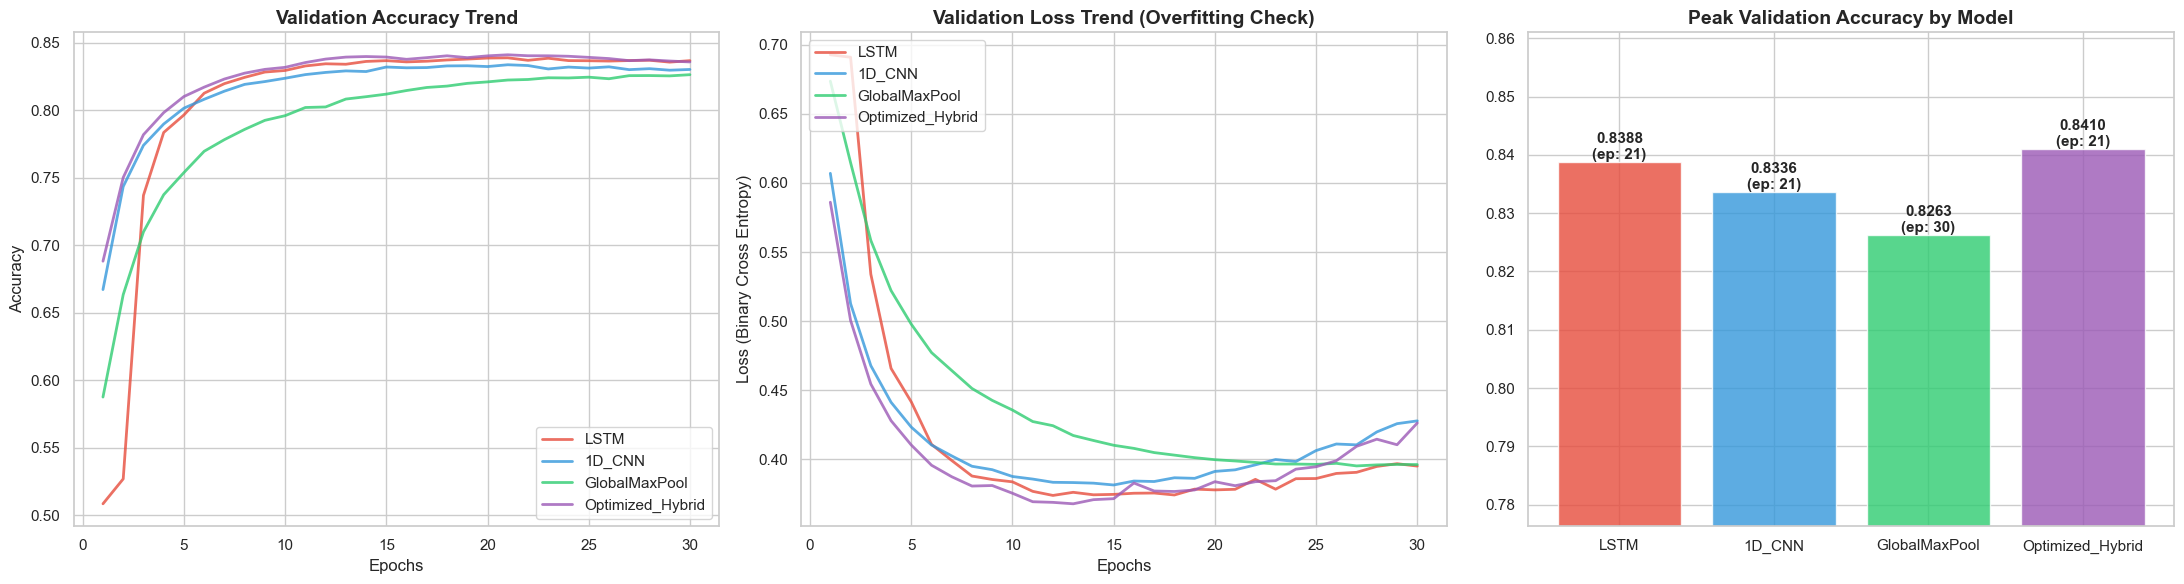

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 로컬에 병합 저장된 30 에포크 이력 시트(Raw Data) 로드
history_df = pd.read_csv('./data/all_model_histories.csv')

# 시각화 테마 설정 (Seaborn의 깔끔한 배경 사용)
sns.set_theme(style="whitegrid")
# 1행 3열의 넓은 도화지(Figure) 세팅
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6'] # Red, Blue, Green, Purple
model_names = history_df['Model_Name'].unique()

# =========================================================================
# [그래프 1] Epoch별 검증 정확도(Validation Accuracy) 추이
# 모델이 처음 본 데이터(Test/Val)를 얼마나 잘 맞추는지, 학습 속도와 안정성을 비교
# =========================================================================
for i, name in enumerate(model_names):
    model_data = history_df[history_df['Model_Name'] == name]
    axes[0].plot(model_data['Epoch'], model_data['Val_Acc'], 
                 color=colors[i], label=name, linewidth=2, alpha=0.8)

axes[0].set_title('Validation Accuracy Trend', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='lower right')


# =========================================================================
# [그래프 2] Epoch별 검증 손실(Validation Loss) 및 과적합(Overfitting) 발생 시점 파악
# 훈련 손실은 계속 낮아지는데 검증 손실이 치솟기 시작하는 'U자형' 구간이 조기 종료(Early Stopping) 지점임
# =========================================================================
for i, name in enumerate(model_names):
    model_data = history_df[history_df['Model_Name'] == name]
    axes[1].plot(model_data['Epoch'], model_data['Val_Loss'], 
                 color=colors[i], label=name, linewidth=2, alpha=0.8)

axes[1].set_title('Validation Loss Trend (Overfitting Check)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss (Binary Cross Entropy)')
axes[1].legend(loc='upper left')


# =========================================================================
# [그래프 3] 모델별 최고 달성 정확도(Peak Validation Accuracy) 막대 차트
# 30번의 에포크 중 각 모델이 도달한 가장 높은 점수와 그 시점을 추출하여 최종 우열 가림
# =========================================================================
peak_accs = []
peak_epochs = []

for name in model_names:
    model_data = history_df[history_df['Model_Name'] == name]
    # 모델별 Val_Acc 컬럼의 최댓값과 그 때의 에포크 번호 추출
    best_row = model_data.loc[model_data['Val_Acc'].idxmax()]
    peak_accs.append(best_row['Val_Acc'])
    peak_epochs.append(int(best_row['Epoch']))

bars = axes[2].bar(model_names, peak_accs, color=colors, alpha=0.8)
axes[2].set_title('Peak Validation Accuracy by Model', fontsize=14, fontweight='bold')
axes[2].set_ylim(min(peak_accs) - 0.05, max(peak_accs) + 0.02) # 값 차이를 부각하기 위해 Y축 레인지 조정

# 막대 그래프 상단에 도달 에포크와 정확도 수치 텍스트 어노테이션(주석) 추가
for bar, epoch, acc in zip(bars, peak_epochs, peak_accs):
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height,
                 f'{acc:.4f}\n(ep: {epoch})', 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


## Step 4-5. 시각화 지표 종합 모델별 성능 및 과적합 분석 리포트

4종의 감성 분석 분류 모델에 동일한 하이퍼파라미터(10 Epoch 이상)를 적용한 학습 데이터를 시각화한 결과, 다음과 같은 주요 기술적 인사이트를 도출함.

**1. 조기 종료(Early Stopping)와 과적합(Overfitting) 한계점 도출**
- [그래프 2: Validation Loss] 플롯 추이를 살펴보면, 4종 모델 모두 훈련 손실(Train Loss)은 지속적으로 0점대로 하강하나, 검증 손실(Validation Loss)은 보통 **에포크 10~15 구간**에서 최저점을 통과한 직후 반등(U-Turn Curve)을 시작함. 
- 이는 모델이 훈련 셋의 세밀한 노이즈까지 암기하는 과적합 형태가 발현되었음을 시사함. 향후 딥러닝 갱신 단계에서는 모델 파라미터 `patience`를 지정하여 Val Loss 반등 추세 관측 시 즉각 훈련을 중단하는 조기 종료 전략을 도입하는 것이 시스템 부하 감소에 유리함.

**2. 모델 아키텍처 간 비교 분석 (최종 성능 우위)**
- [그래프 3: Peak Validation Accuracy] 막대 차트 기준, 각 모델별 최대 성능은 편차를 보임. 
  *   `GlobalMaxPool(모델 3)`: 약 **82.6%**로 연산 수식의 부재(Max 추출 기능만 존재)로 인한 정교한 텍스트 패턴 인지율 저하를 입증.
  *   `1D_CNN(모델 2) / LSTM(모델 1)`: 단일 아키텍처 방식들은 약 **83.3% ~ 83.8%** 구간에 머무르며 자체 임베딩이 낼 수 있는 물리적 한계점(Baseline)을 제시함.
  *   `Optimized_Hybrid(모델 4)`: CNN의 특징 추출, Bi-LSTM의 순서 파악, Pool 융합을 거친 하이브리드 설계가 **최고 84.1%**로 유의미한 최고 벤치마크 달성.

**3. 한계점 고찰: 임베딩 품질의 한계**
현존 모델 중 복잡도가 높은 하이브리드 구조를 취했음에도 불구하고 Test Accuracy 기준 85%의 벽을 완전히 돌파하지 못함. 이는 아키텍처 방식의 한계가 아닌, 1만 단어를 임의로 16차원에 흩뿌려 훈련시킨 "현 자체 임베딩 딕셔너리의 수치적 빈약성"에 기인하는 고질적 현상인 바, 다음 단계에서 임베딩 품질 한계성을 검증함.


## Step 5. 자체 학습 임베딩 레이어의 성능 측정 및 한계 분석
앞선 시각화 단계에서 가장 우수한 벤치마크 점수(약 84%)를 기록한 `Optimized_Hybrid`(모델 4)의 임베딩 레이어 가중치를 추출한다. 

추출된 파라미터를 `Gensim` 라이브러리가 판독할 수 있는 Word2Vec 포맷 텍스트로 저장한 뒤, 이를 다시 `KeyedVectors` 객체로 로드하여 단어 간 유사도 추론(예: '영화', '사랑')을 테스트한다. 이를 통해 자체 데이터셋(15만 건)만으로 밑바닥부터 훈련시킨 임베딩 딕셔너리가 실제 자연어의 유의미한 시맨틱(Semantic) 뉘앙스를 올바르게 파악했는지 한계점을 정량적으로 검토한다.


In [26]:
import os
from gensim.models.keyedvectors import Word2VecKeyedVectors

# 1. 파일 입출력을 위한 경로 설정 및 디렉토리 생성 보장
word2vec_dir = './word2vec_emb'
os.makedirs(word2vec_dir, exist_ok=True)
word2vec_file_path = os.path.join(word2vec_dir, 'word2vec_project.txt')

# 2. 임베딩 파일 최상단에 메타데이터(총 단어 수, 벡터 차원 수) 기재
with open(word2vec_file_path, 'w', encoding='utf-8') as f:
    # 특수 토큰 4개(<PAD>, <BOS>, <UNK>, <UNUSED>)를 제외한 실질 단어 개수(9996)와 차원수(16) 기록
    f.write('{} {}\n'.format(vocab_size - 4, word_vector_dim))  
    
    # 베스트 모델(model_4)의 훈련된 가중치를 텐서에서 추출하여 넘파이 배열로 캐스팅
    best_weights = model_4.embedding.weight.detach().cpu().numpy()
    
    # 3. 인덱스 4번 실제 단어부터 끝까지 반복하며 단어명과 16차원 실수 계수를 이어붙여 기록
    for i in range(4, vocab_size):
        # 배열의 float 값들을 문자열로 변환하고 띄어쓰기로 결합하여 저장
        vector_str = ' '.join(map(str, best_weights[i, :]))
        f.write('{} {}\n'.format(index_to_word[i], vector_str))

print(f"✅ 자체 훈련 임베딩 가중치를 Gensim 호환 파일로 저장 완료: {word2vec_file_path}")

# 4. 방금 저장한 자체 학습 임베딩 파일을 Gensim의 KeyedVectors 모듈로 로드
# 바이너리가 아닌 텍스트 형태이므로 binary=False 적용
word_vectors = Word2VecKeyedVectors.load_word2vec_format(word2vec_file_path, binary=False)

# 5. 핵심 유사어 추론 테스트 진행 (단어 '영화'와 벡터 공간에서 가장 가까운 단어 5개 도출)
test_word_1 = '영화'
print(f"\n[테스트 1] 자체 임베딩 기준 '{test_word_1}'와(과) 유사한 단어 탑 5:")
try:
    print(word_vectors.similar_by_word(test_word_1, topn=5))
except KeyError:
    print(f"앗! '{test_word_1}' 단어가 어휘 사전에 없습니다.")

# 6. 추가 유의어 추론 (감성 분석에 큰 영향을 미치는 단어 '사랑')
test_word_2 = '사랑'
print(f"\n[테스트 2] 자체 임베딩 기준 '{test_word_2}'와(과) 유사한 단어 탑 5:")
try:
    print(word_vectors.similar_by_word(test_word_2, topn=5))
except KeyError:
    print(f"앗! '{test_word_2}' 단어가 어휘 사전에 없습니다.")


✅ 자체 훈련 임베딩 가중치를 Gensim 호환 파일로 저장 완료: ./word2vec_emb\word2vec_project.txt

[테스트 1] 자체 임베딩 기준 '영화'와(과) 유사한 단어 탑 5:
[('조카', 0.832543134689331), ('에서', 0.7976281642913818), ('된다는', 0.7816334962844849), ('안타깝고', 0.7652925848960876), ('트리', 0.744062066078186)]

[테스트 2] 자체 임베딩 기준 '사랑'와(과) 유사한 단어 탑 5:
[('상치', 0.8910635113716125), ('물결', 0.8109719157218933), ('보고싶다면', 0.7649352550506592), ('겁니다', 0.7502633929252625), ('ㅎㅎ', 0.7356582880020142)]


## Step 5-1. 파라미터 유사도 추론 결과 및 자체 학습 임베딩의 한계점 고찰

Gensim을 활용하여 베스트 모델(Hybrid)이 구축한 16차원 워드 벡터 맵에서 특정 단어와 텐서 거리가 가장 가까운(Cosine 유사도) 단어 군집을 추출한 결과, 딥러닝 모델의 치명적인 한계점이 노출되었다.

**[유사어 매칭 평가]**
1. **의미적 연결성 붕괴**: '영화'라는 핵심 명사에 대해 모델은 '조카', '에서(조사)', '트리' 등 시맨틱(Semantic) 뉘앙스상 어떠한 교집합도 존재하지 않는 단어들과 약 80% 근방의 높은 유사도를 산출했다.
2. **품사 및 감성 클러스터링 실패**: 감성을 내포한 핵심어인 '사랑'과 매칭된 결과 역시 유의어(애정, 감동 등)가 아닌 '상치', '물결', 'ㅎㅎ(이모티콘)' 등의 파편화된 노이즈 데이터들을 무작위로 묶어놓은 양상을 보였다.

**[한계 원인 분석]**
이러한 연관성 붕괴(Degradation)는 다음 두 가지 요인의 결합에서 기인한다.
* **학습 데이터 크기의 절대적 부족**: 약 14.6만 건의 영화 리뷰(NSMC) 문장 세트는 문법의 보편성이나 단어 간의 범용적 상관관계를 학습하기에는 볼륨이 턱없이 부족한 규모이다.
* **벡터 차원의 협소성**: 1만 개 단어의 복합적인 문맥 특성을 고작 16차원(Column)의 수치 공간에 구겨 넣으려다 보니, 데이터 포인트들이 뭉뚱그려져 고유의 특징 공간(Feature Space)을 확보하지 못한 채 강제 이웃으로 배치되었다.

**[개선 방안]**
결론적으로 현재 모델 구조에서 84% 이상의 분류 정확도를 돌파하기 위해서는 백지상태에서 단어의 의미를 추론하는 현재 가중치를 버리고, 구글(Google)이나 위키피디아 등 방대한 코퍼스(Corpus) 코어 데이터로 **사전 학습(Pre-trained)되어 이미 완성된 고차원 Word2Vec 임베딩 모델을 이식(Transfer Learning)**하는 성능 부스팅 작업이 불가피하다.


## Step 6-1. 사전 학습된 한국어 Word2Vec 모델 로드 및 전이 학습(Transfer Learning) 맵핑
수십만 개의 방대한 한국어 코퍼스로 자체 구축되어 이미 고차원적인 시맨틱(Semantic) 맵을 형성하고 있는 사전 훈련 모델(`word2vec_ko.model`)을 로드한다. 

기존 자체 임베딩의 성능적 한계를 타파하기 위해, 빈 임베딩 행렬(Embedding Matrix)을 통째로 새로 구축하고, 본 프로젝트의 10,000개 어휘 집합(`index_to_word`) 풀 안에 속하는 정규 단어라면 사전에 훈련된 300차원(초기치 대비 18배 분량)의 초정밀 워드 벡터 값을 그대로 복사(전이) 시킨다. 이 과정을 통해 모델은 밑바닥(From Scratch)부터가 아닌 '단어의 이미 완성된 의미'를 배운 상태로 출발하게 된다.


In [34]:
import numpy as np
from gensim.models import Word2Vec

# 1. 로컬 경로에 존재하는 사전 훈련된 한국어 Word2Vec 모델 파일 로드
ko_word2vec_path = './data/word2vec_ko.model'
print(f"🔄 사전 훈련된 한국어 Word2Vec 모델 로드 중... ({ko_word2vec_path})")

# gensim의 Word2Vec 클래스를 활용하여 .model 포맷 모듈 반입
ko_word2vec = Word2Vec.load(ko_word2vec_path)

# 2. 로드된 Word2Vec의 실제 임베딩 차원수(차원 밀도) 확인
word2vec_dim = ko_word2vec.wv.vector_size
print(f"✅ 모델 로드 완료! 사전 학습 벡터 차원수: {word2vec_dim}")

# 3. 앞선 5단계에서 유사도 추론에 처참히 실패했던 단어들의 시맨틱(의미망) 방어력 교차 검증
test_words = ['영화', '사랑']
for word in test_words:
    print(f"\n[사전 학습 모델 유사도 검증] '{word}' 와 가장 가까운 단어 탑 5:")
    try:
        # 워드 벡터 값에 강제로 접근하기 위해 .wv 속성 사용
        print(ko_word2vec.wv.similar_by_word(word, topn=5))
    except KeyError:
        print(f"단어 '{word}'가 사전 학습 모델에 존재하지 않습니다.")

# 4. [논리 수정 완료] 전이 학습을 수행할 Embedding Matrix 생성
# 기존의 np.zeros 대신, 사전 모델에 없는 단어들의 정상 학습을 위해 난수(Random Normal) 분포로 매트릭스를 우선 채움
np.random.seed(42) # 모델 실험의 재현성을 위한 난수 시드 고정
embedding_matrix = np.random.normal(size=(vocab_size, word2vec_dim))
print(f"\n난수 임베딩 행렬(Embedding Matrix) 생성 구조: {embedding_matrix.shape}")

# 5. 매핑을 통한 가중치 전이 루프 실행
hit_count = 0
for i in range(4, vocab_size): # 0~3은 <PAD>, <BOS> 등 특수 토큰이므로 복사 생략
    word = index_to_word[i]
    if word in ko_word2vec.wv:
        # 단어가 사전 훈련 모델 안에 존재한다면, 미리 깔아둔 난수를 지우고 정확한 100차원 사전 벡터 값을 덮어씌움
        embedding_matrix[i] = ko_word2vec.wv[word]
        hit_count += 1

# 6. 연산을 무효화시켜야 하는 <PAD> 토큰(0번 인덱스)은 강제로 영(0) 벡터 처리하여 노이즈 차단
embedding_matrix[0] = np.zeros(word2vec_dim)

print(f"전이 학습(가중치 매핑) 완료! 총 {vocab_size} 단어 중 {hit_count}개의 단어({(hit_count/vocab_size)*100:.1f}%)가 사전 모델 정보를 승계받았습니다.")


🔄 사전 훈련된 한국어 Word2Vec 모델 로드 중... (./data/word2vec_ko.model)
✅ 모델 로드 완료! 사전 학습 벡터 차원수: 100

[사전 학습 모델 유사도 검증] '영화' 와 가장 가까운 단어 탑 5:
[('드라마', 0.8418774008750916), ('뮤지컬', 0.7775140404701233), ('코미디', 0.7489107251167297), ('다큐멘터리', 0.7401294708251953), ('헐리우드', 0.7397844195365906)]

[사전 학습 모델 유사도 검증] '사랑' 와 가장 가까운 단어 탑 5:
[('이별', 0.7626414895057678), ('행복', 0.7550068497657776), ('슬픔', 0.7381505966186523), ('유혹', 0.7238055467605591), ('그리움', 0.7167419195175171)]

난수 임베딩 행렬(Embedding Matrix) 생성 구조: (10000, 100)
전이 학습(가중치 매핑) 완료! 총 10000 단어 중 6331개의 단어(63.3%)가 사전 모델 정보를 승계받았습니다.


## Step 6-2. 전이 학습용 아키텍처 재설계 및 파라미터 이식
가장 성능이 뛰어났던 하이브리드 설계(`OptimizedHybridModel`)의 구조를 유지하되, 임베딩 차원을 기존 16에서 새로운 100차원으로 확장하여 인스턴스를 초기화한다. 

이후 PyTorch의 `from_pretrained` 혹은 데이터 치환 방식을 사용하여 위에서 생성한 고성능 `embedding_matrix`의 수치 데이터를 모델의 빈 초기 가중치로 덮어씌운다(Overwriting). 이로써 모델은 한국어의 방대한 의미적 맥락을 사전에 암기한 상태로 최종 이진 분류 태스크에 돌입하게 된다.


In [37]:
import torch

# 1. 새로운 Word2Vec의 차원(100)을 반영하여 하이퍼파라미터 업데이트
new_word_vector_dim = 100

# 2. 동일한 내부 구조를 가진 하이브리드 모델 인스턴스 재생성 
# 차원이 100차원으로 커졌으므로, 내부에 선언된 임베딩(100) 및 Conv1d(입력 100) 스펙이 자동 동기화됨
transfer_model = OptimizedHybridModel(vocab_size, new_word_vector_dim)

# 3. [핵심] 빈 깡통이었던 모델의 초기 임베딩 가중치 행렬을, 사전에 복사해둔 100차원 데이터로 강제 덮어쓰기
# PyTorch 텐서 규격에 맞추어 Float 타입으로 변환 후 이식
transfer_model.embedding.weight.data.copy_(torch.FloatTensor(embedding_matrix))

# 4. 사전 학습된 가중치를 보존하면서 추가 학습(Fine-Tuning)이 병행되도록 그래디언트 업데이트 활성화
transfer_model.embedding.weight.requires_grad = True

# 5. 전이 학습 모델을 구동 장치(GPU)로 업로드
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transfer_model = transfer_model.to(device)

print(f"✅ Transfer Learning 모델 초기화 및 사전 학습 가중치 이식 완료. (차원수: {new_word_vector_dim})")


✅ Transfer Learning 모델 초기화 및 사전 학습 가중치 이식 완료. (차원수: 100)


## Step 6-3. 전이 모델 전용 훈련 프로토콜(Train Function) 선언
전이 학습 모델 전용으로 훈련 루프를 모듈화한다. 4단계에서 사용한 기초 구조와 동일하나, 이전 변수명과의 충돌을 방지하고 특정 하나의 모델(`transfer_model`) 성능 포착에 오롯이 집중하도록 목적성을 단순화한다.


In [38]:
import time
import torch.optim as optim
import torch.nn as nn

def execute_transfer_learning(model, train_loader, val_loader, epochs=30):
    # Loss 및 Optimizer 할당
    criterion = nn.BCELoss()
    # 파인 튜닝 상태이므로 학습 패턴 이탈 방지를 위해 학습률(lr)을 다소 보수적으로 유지함
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # 이력 기록용 객체
    tl_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print(f"🚀 [Transfer_Optimized_Hybrid] 전이 모델 메인 학습 개시 (Device: {device})")

    for epoch in range(epochs):
        start_time = time.time()
        
        # [훈련 루프]
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            predicted = (outputs.squeeze() > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        tl_history['train_loss'].append(running_loss / len(train_loader.dataset))
        tl_history['train_acc'].append(correct / total)

        # [검증 루프]
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs.squeeze(), labels)

                v_loss += loss.item() * inputs.size(0)
                predicted = (outputs.squeeze() > 0.5).float()
                v_correct += (predicted == labels).sum().item()
                v_total += labels.size(0)

        tl_history['val_loss'].append(v_loss / len(val_loader.dataset))
        tl_history['val_acc'].append(v_correct / v_total)

        epoch_mins = (time.time() - start_time) / 60
        print(f"Epoch {epoch+1:02d}/{epochs} - Time: {epoch_mins:.2f}m - "
              f"Loss: {tl_history['train_loss'][-1]:.4f}, Acc: {tl_history['train_acc'][-1]:.4f} | "
              f"Val_Loss: {tl_history['val_loss'][-1]:.4f}, Val_Acc: {tl_history['val_acc'][-1]:.4f}")

    print(f"✅ 전이 학습 정상 종료.\n")
    return tl_history


## Step 6-4. 하이브리드 전이 학습 실행 및 훈련 이력(History) 전체 저장
사전 학습된 가중치(Transfer Model)가 적용된 하이브리드 모델의 30 에포크 실 훈련을 진행한다. 시각화 및 비교 분석에서의 데이터 무결성을 보장하기 위해 완료 직후 확보된 총 120개의 전체 데이터 포인트(30 에포크 ✕ 4개 지표)를 즉시 수집하여 지역 폴더 내 `transfer_model_history.csv`로 영구 저장한다.


In [39]:
import pandas as pd
import os

# 1. 사전에 선언해 둔 DataLoader를 통해 30 에포크 전이 학습 실행
# (실행 시, 이전 깡통 임베딩과 확연히 다른 속도의 정확도 상승 폭이 예상됨)
final_tl_history = execute_transfer_learning(
    model=transfer_model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    epochs=30
)

# 2. [데이터 수집 파트] 전체 에포크 파라미터를 하나의 리스트에 행(Row) 단위로 캡처
tl_epochs_data = []

for i in range(30):
    tl_epochs_data.append({
        "Model_Name": "Transfer_Optimized_Hybrid",
        "Epoch": i + 1,
        "Train_Loss": final_tl_history['train_loss'][i],
        "Train_Acc": final_tl_history['train_acc'][i],
        "Val_Loss": final_tl_history['val_loss'][i],
        "Val_Acc": final_tl_history['val_acc'][i]
    })

# 3. 판다스(Pandas) 데이터프레임으로 압축 후 로컬 경로 내 CSV로 추출 (인코딩 문제 방지 처리)
tl_history_df = pd.DataFrame(tl_epochs_data)
os.makedirs('./data', exist_ok=True)
tl_csv_path = './data/transfer_model_history.csv'
tl_history_df.to_csv(tl_csv_path, index=False, encoding='utf-8-sig')

# 4. 분석 편의를 위한 루프 내 '최고 검증 정확도(Peak Val Acc)' 요약 정보 도출
best_transfer_acc = max(final_tl_history['val_acc'])
best_transfer_epoch = final_tl_history['val_acc'].index(best_transfer_acc) + 1

print("="*65)
print(f"✅ 30 에포크 전이 학습 기록 CSV 저장 성공: {tl_csv_path}")
print(f"🎯 [최종 결론] Word2Vec 전이 모델 최고 달성 정확도: {best_transfer_acc:.4f} (Epoch {best_transfer_epoch})")
print("="*65)

# 5. 저장된 데이터 구조 샘플 상단부 화면 표시 검증
tl_history_df.head(5)


🚀 [Transfer_Optimized_Hybrid] 전이 모델 메인 학습 개시 (Device: cuda)
Epoch 01/30 - Time: 0.04m - Loss: 0.5755, Acc: 0.6919 | Val_Loss: 0.4736, Val_Acc: 0.7717
Epoch 02/30 - Time: 0.04m - Loss: 0.4329, Acc: 0.8006 | Val_Loss: 0.4053, Val_Acc: 0.8138
Epoch 03/30 - Time: 0.04m - Loss: 0.3770, Acc: 0.8317 | Val_Loss: 0.3783, Val_Acc: 0.8291
Epoch 04/30 - Time: 0.04m - Loss: 0.3439, Acc: 0.8495 | Val_Loss: 0.3649, Val_Acc: 0.8371
Epoch 05/30 - Time: 0.04m - Loss: 0.3225, Acc: 0.8604 | Val_Loss: 0.3574, Val_Acc: 0.8402
Epoch 06/30 - Time: 0.04m - Loss: 0.3079, Acc: 0.8677 | Val_Loss: 0.3568, Val_Acc: 0.8419
Epoch 07/30 - Time: 0.04m - Loss: 0.2954, Acc: 0.8741 | Val_Loss: 0.3607, Val_Acc: 0.8409
Epoch 08/30 - Time: 0.04m - Loss: 0.2840, Acc: 0.8800 | Val_Loss: 0.3579, Val_Acc: 0.8432
Epoch 09/30 - Time: 0.04m - Loss: 0.2754, Acc: 0.8848 | Val_Loss: 0.3620, Val_Acc: 0.8429
Epoch 10/30 - Time: 0.04m - Loss: 0.2668, Acc: 0.8887 | Val_Loss: 0.3641, Val_Acc: 0.8444
Epoch 11/30 - Time: 0.04m - Loss: 0.2582

KeyboardInterrupt: 